# 1장 - 인과추론 소개



## 1.1 인과추론의 개념



## 1.2 인과추론의 목적
 


## 1.3 머신러닝과 인과추론
 


## 1.4 연관관계와 인과관계
 

In [2]:
import pandas as pd
import numpy as np
from scipy.special import expit
import seaborn as sns
from matplotlib import pyplot as plt
from cycler import cycler



default_cycler = (cycler(color=['0.3', '0.5', '0.7', '0.5']) +
                  cycler(linestyle=['-', '--', ':', '-.']) + 
                  cycler(marker=['o', 'v', 'd', 'p']))

color=['0.3', '0.5', '0.7', '0.5']
linestyle=['-', '--', ':', '-.']
marker=['o', 'v', 'd', 'p']

plt.rc('axes', prop_cycle=default_cycler)
plt.rc('font', size=20)

In [3]:
data = pd.read_csv("./data/xmas_sales.csv")
data.head(6)

,store,weeks_to_xmas,avg_week_sales,is_on_sale,weekly_amount_sold
0,1,3,12.98,1,219.60
1,1,2,12.98,1,184.70
2,1,1,12.98,1,145.75
3,1,0,12.98,0,102.45
4,2,3,19.92,0,103.22
5,2,2,19.92,0,53.73


### 1.4.1 처치와 결과


### 1.4.2 인과추론의 근본적인 문제
 


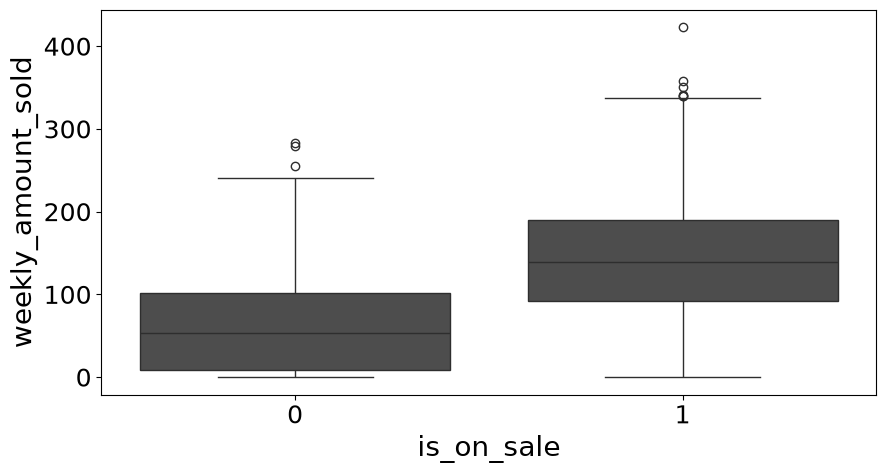

In [4]:
fig, ax = plt.subplots(1,1, figsize=(10,5))
sns.boxplot(y="weekly_amount_sold", x="is_on_sale", data=data, ax=ax)

ax.set_xlabel("is_on_sale", fontsize = 20)
ax.set_ylabel("weekly_amount_sold", fontsize = 20)
ax.tick_params(axis='both', which='major', labelsize=18)

### 1.4.3 인과모델
 

### 1.4.4 개입


### 1.4.5 개별 처치효과



### 1.4.6 잠재적 결과
 
### 1.4.7 일치성 및 SUTVA 가정


### 1.4.8 인과 추정량



### 1.4.9 인과 추정량 예시
 

In [5]:
pd.DataFrame(dict(
    i= [1,2,3,4,5,6],
    y0=[200,120,300, 450,600,600],
    y1=[220,140,400, 500,600,800],
    t= [0,0,0,1,1,1],
    x= [0,0,1,0,0,1],
)).assign(
    y = lambda d: (d["t"]*d["y1"] + (1-d["t"])*d["y0"]).astype(int),
    te=lambda d: d["y1"] - d["y0"]
)

,i,y0,y1,t,x,y,te
0,1,200,220,0,0,200,20
1,2,120,140,0,0,120,20
2,3,300,400,0,1,300,100
3,4,450,500,1,0,500,50
4,5,600,600,1,0,600,0
5,6,600,800,1,1,800,200


In [6]:
pd.DataFrame(dict(
    i= [1,2,3,4,5,6],
    y0=[200,120,300, np.nan, np.nan, np.nan,],
    y1=[np.nan, np.nan, np.nan, 500,600,800],
    t= [0,0,0,1,1,1],
    x= [0,0,1,0,0,1],
)).assign(
    y = lambda d: np.where(d["t"]==1, d["y1"], d["y0"]).astype(int),
    te=lambda d: d["y1"] - d["y0"]
)

,i,y0,y1,t,x,y,te
0,1,200.0,NaN,0,0,200,NaN
1,2,120.0,NaN,0,0,120,NaN
2,3,300.0,NaN,0,1,300,NaN
3,4,NaN,500.0,1,0,500,NaN
4,5,NaN,600.0,1,0,600,NaN
5,6,NaN,800.0,1,1,800,NaN


## 1.5 편향
 
### 1.5.1 편향식 


 
### 1.5.2 편향의 시각적 가이드
 

<Figure size 640x480 with 0 Axes>

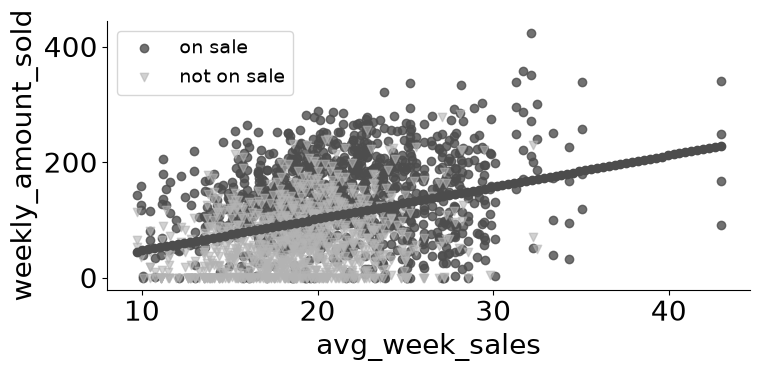

In [7]:
plt.rc('font', size=20)
fig = plt.figure()    

sns.lmplot(data=data,
           ci=None,
           x="avg_week_sales",
           y="weekly_amount_sold",
           scatter=False,
           height=4, aspect=2)

plt.scatter(x=data.query("is_on_sale==1")["avg_week_sales"],
            y=data.query("is_on_sale==1")["weekly_amount_sold"],
            label="on sale",
            color=color[0], alpha=.8, marker=marker[0])

plt.scatter(x=data.query("is_on_sale==0")["avg_week_sales"],
            y=data.query("is_on_sale==0")["weekly_amount_sold"],
            label="not on sale",
            color=color[2], alpha=.6, marker=marker[1])
plt.legend(fontsize="14")
    


## 1.6 처치효과 식별하기
 
### 1.6.1독립성 가정
 

### 1.6.2 랜덤화와 식별
 

## 1.7 요약
 